# 5101 EJERCICIOS CON MATPLOTLIB

El fichero titanic.csv contiene información sobre los pasajeros del Titanic. Crear un dataframe con Pandas y a partir de él generar los siguientes diagramas:
1. Diagrama de sectores con los fallecidos y supervivientes.
2. Histograma con las edades.
3. Diagrama de barras con el número de personas en cada clase.
4. Diagrama de barras con el número de personas fallecidas y supervivientes en cada clase.
5. Diagrama de barras con el número de personas fallecidas y supervivientes acumuladas en cada clase

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
df_titanic = pd.read_csv('C:/Users/Jose Manuel/Documents/VisualStudioCode_Workspace/Repo_CEDAPY/CEDAPY_25_26/ANALISIS_DATOS_PYTHON/NOTEBOOKS/datasets/titanic.csv', sep=',', engine='python')
display(df_titanic.head())
print(df_titanic.describe())


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


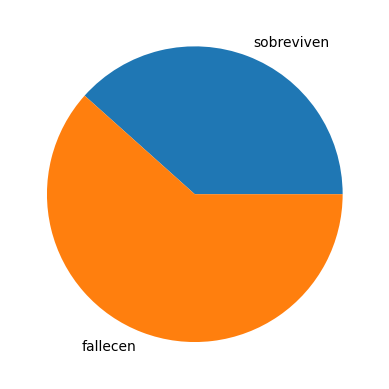

In [16]:

sobrevive = 0
fallece = 0
for pasajeros in df_titanic['Survived']:
    if(pasajeros == 1):
        sobrevive +=1
    else:
        fallece +=1
fig, ax = plt.subplots()
ax.pie([sobrevive,fallece], labels=['sobreviven', 'fallecen'])

#ax.pie(df_titanic['Survived'].value_counts(), labels=['sobreviven', 'fallecen'])
plt.show()



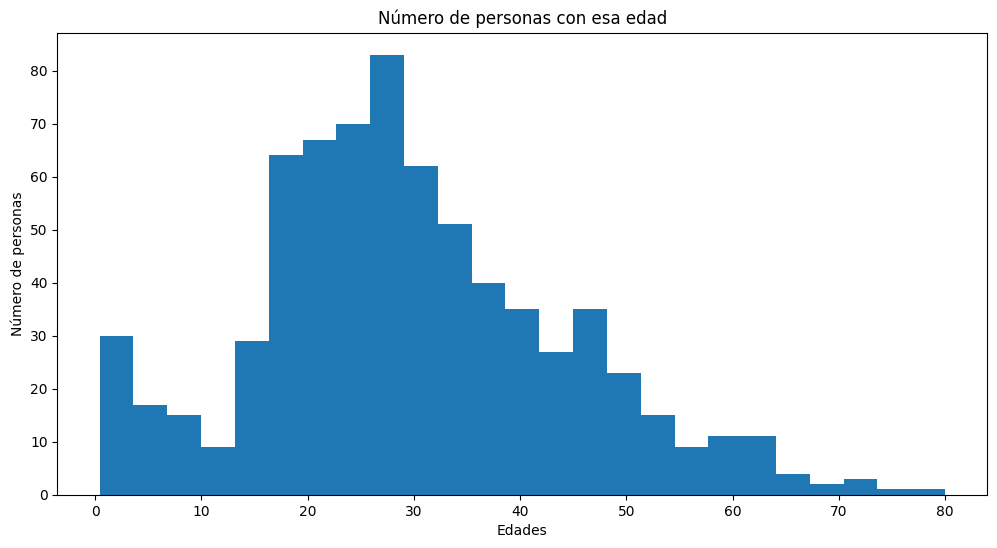

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

edades_sin_nulos = df_titanic['Age'].dropna()
plt.figure(figsize=[12, 6])
plt.hist(edades_sin_nulos, bins=25)
plt.title('Número de personas con esa edad')
plt.xlabel('Edades')
plt.ylabel('Número de personas')
plt.show()

216
184
491


<BarContainer object of 891 artists>

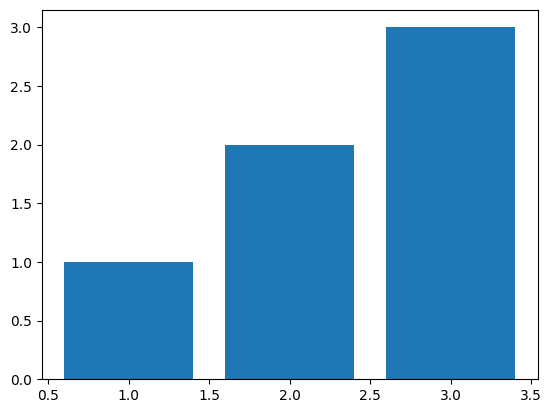

In [39]:

print(df_titanic['Pclass'].value_counts().get(1,0))
print(df_titanic['Pclass'].value_counts().get(2,0))
print(df_titanic['Pclass'].value_counts().get(3,0))
fig, ax = plt.subplots()
ax.bar(df_titanic['Pclass'], df_titanic.groupby('PassengerId')['Pclass'].sum())

El fichero bancos.csv contiene las cotizaciones de los principales bancos de España con : 
- Empresa (nombre de la empresa), 
- Apertura (precio de la acción a la apertura de bolsa), 
- Máximo (precio máximo de la acción durante la jornada), 
- Mínimo (precio mínimo de la acción durante la jornada), 
- Cierre (precio de la acción al cierre de bolsa), 
- Volumen (volumen al cierre de bolsa).     

Construir una función reciba el fichero bancos.csv y cree un diagrama de líneas con las series temporales de las cotizaciones de cierre de cada banco

(102, 7)


,Empresa,Fecha,Apertura,Máximo,Mínimo,Cierre,Volumen
0,Banco Sabadell,2021-04-01,0.4591,0.4591,0.4445,0.4553,30084389
1,Banco Sabadell,2021-04-06,0.4630,0.4778,0.4581,0.4656,44336977
2,Banco Sabadell,2021-04-07,0.4650,0.4705,0.4626,0.4673,22517116
3,Banco Sabadell,2021-04-08,0.4662,0.4695,0.4536,0.4607,30800345
4,Banco Sabadell,2021-04-09,0.4607,0.4644,0.4512,0.4600,35703383


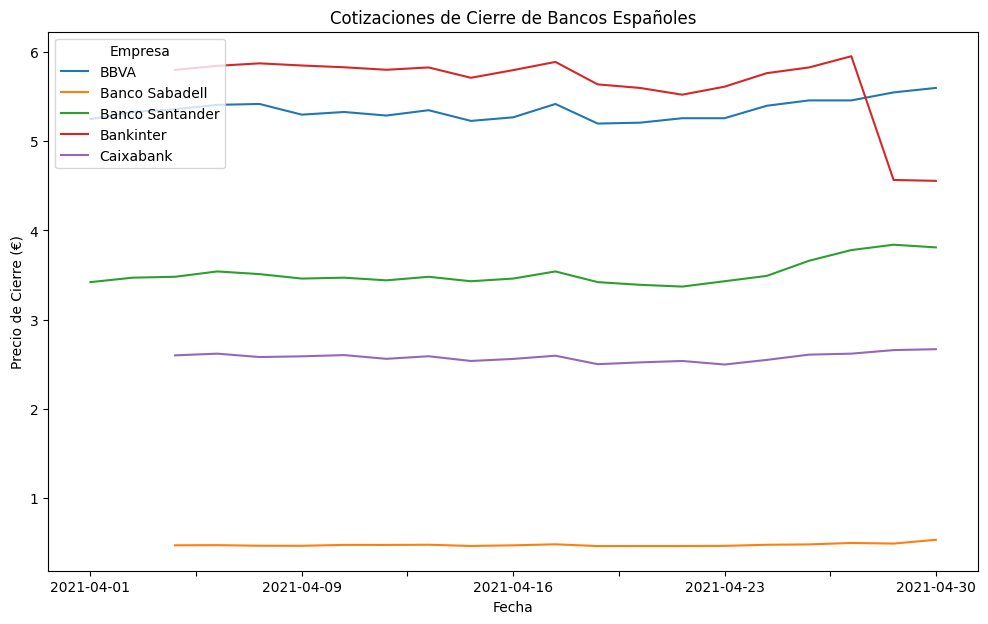

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df_bancos = pd.read_csv('C:/Users/Jose Manuel/Documents/VisualStudioCode_Workspace/Repo_CEDAPY/CEDAPY_25_26/ANALISIS_DATOS_PYTHON/NOTEBOOKS/datasets/bancos.csv', sep=',', engine='python')
print(df_bancos.shape)
display(df_bancos.head())
# Configurar la columna 'Fecha' como índice del DataFrame
df_bancos.set_index('Fecha', inplace=True)
# Preparar los datos para la gráfica: 
        # Usamos pivot_table para reestructurar el dataframe
        # Índice: Fecha, Columnas: Empresa, Valores: Cierre
df_bank = df_bancos.pivot_table(index='Fecha', columns='Empresa', values='Cierre')
# Crear el diagrama de líneas
plt.figure(figsize=(12, 7))
df_bank.plot(kind='line', ax=plt.gca())
 # Añadir títulos y etiquetas
plt.title('Cotizaciones de Cierre de Bancos Españoles')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre (€)')
plt.legend(title='Empresa', loc = 'upper left')

plt.show()


Escribir una función que reciba un dataframe de Pandas con los ingresos y gastos de una empresa por meses y devuelva un diagrama de líneas con dos líneas, una para los ingresos y otra para los gastos.    
El diagrama debe tener una leyenda identificando la línea de los ingresos y la de los gastos, un título con el nombre "Evolución de ingresos y gastos" y el eje y debe empezar en 0

,mes,ingresos,gastos
0,enero,25000,4000
1,febrero,10000,5000
2,marzo,30000,45000
3,abril,40000,6000
4,mayo,50000,8000


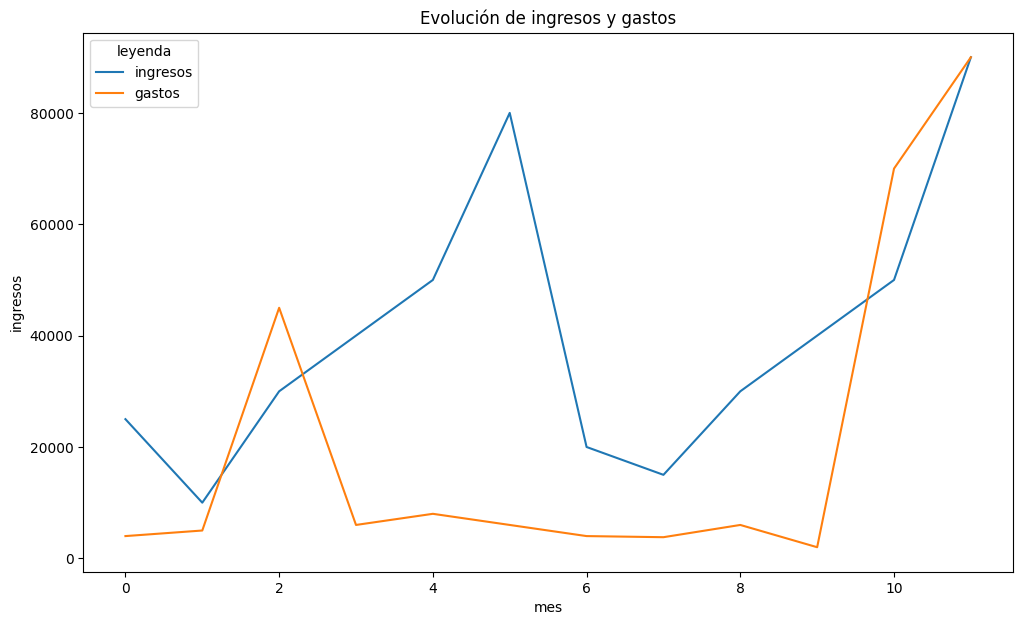

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
ingresos = [25000,10000,30000,40000,50000,80000,20000,15000,30000,40000,50000,90000]
gastos =[4000,5000,45000,6000,8000,6000,4000,3800,6000,2000,70000,90000]
meses = ['enero','febrero', 'marzo','abril', 'mayo', 'junio','julio','agosto','septiembre','octubre','noviembre','diciembre']

datos = {'mes': meses,
         'ingresos' : ingresos,
         'gastos' :gastos
         }


df_Empresa = pd.DataFrame(datos)
display(df_Empresa.head())

df_pivot = df_Empresa.pivot_table(index='mes', columns='ingresos', values='gastos')
plt.figure(figsize=(12, 7))
df_Empresa.plot(kind='line', ax=plt.gca())
plt.title('Evolución de ingresos y gastos')
plt.legend(title='leyenda')
plt.xlabel('mes')
plt.ylabel('ingresos')
plt.show()


Escribir una función que reciba una serie de Pandas con el número de ventas de un producto por años y una cadena con el tipo de gráfico a generar (líneas, barras, sectores, areas) y devuelva un diagrama del tipo indicado con la evolución de las ventas por años y con el título "Evolución del número de ventas"

,product,ventas,year
0,coca_cola,3000,2020
1,coca_cola,2000,2021
2,coca_cola,6000,2022
3,coca_cola,500,2023


C:\Users\Jose Manuel\AppData\Local\Temp\ipykernel_21340\2611532236.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Coca_Cola')


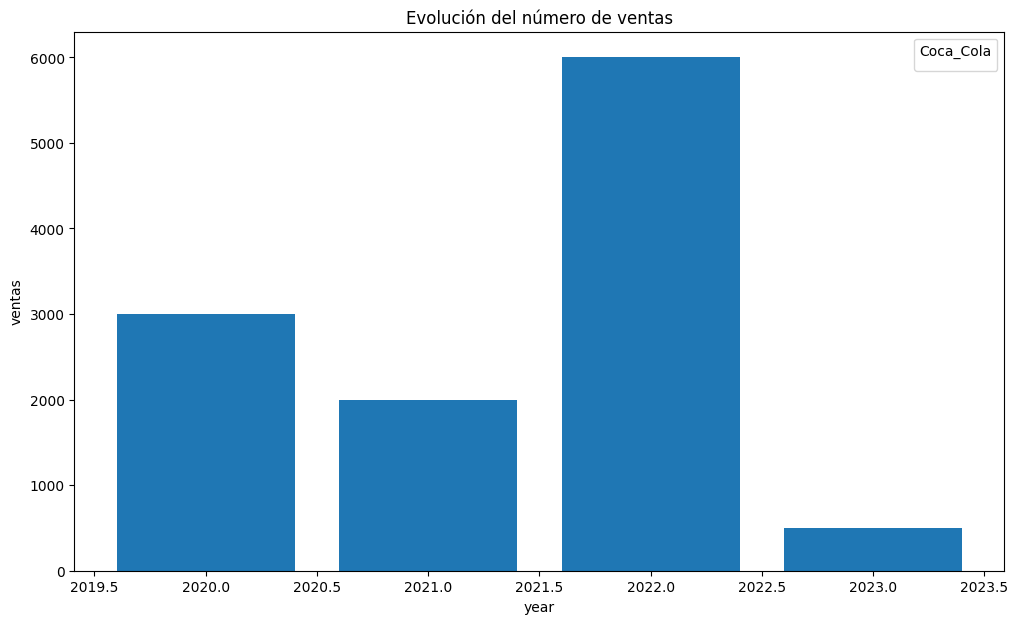

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
producto = 'coca_cola'
num_ventas = [3000,2000,6000,500]
anios = [2020,2021,2022,2023]
datos_productos = {
    'product' : producto,
    'ventas' : num_ventas,
    'year' : anios
}
df_ventas_anio = pd.DataFrame(datos_productos)
display(df_ventas_anio.head())

def graficos_producto(df, tipo):
    
    fig, ax = plt.subplots(figsize=(12, 7))
    if (tipo == 'lineas'):
        ax.plot(df['year'], df['ventas'])
        
    elif (tipo == 'barras'):
        ax.bar(df['year'], df['ventas'])
       
    elif (tipo == 'sectores'):
        ax.pie(df['ventas'], labels=df['year'])
       
    elif (tipo == 'areas'):
        ax.fill_between(df['year'], df['ventas'])
       

    plt.title('Evolución del número de ventas')
    
    ax.set_xlabel('year')
    ax.set_ylabel('ventas')
    ax.legend(title='Coca_Cola')
    plt.show()

graficos_producto(df_ventas_anio, 'barras')

Escribir una función que reciba una serie de Pandas con el número de ventas de un producto durante los meses de un trimestre y un título y cree un diagrama de sectores con las ventas en formato png con el título dado. El diagrama debe guardarse en un fichero con formato png y el título dado.

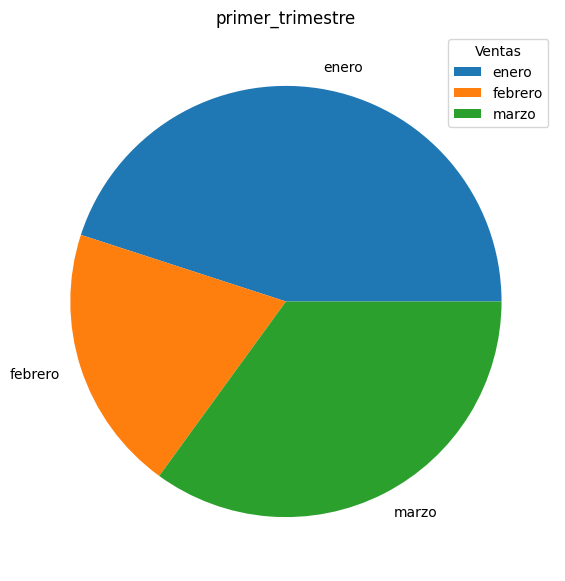

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

meses = ['enero', 'febrero', 'marzo']
ventas = [45000,20000,35000]
datos = {
    'mes': meses,
    'venta': ventas
}

df = pd.DataFrame(datos)
def ventas(df, titulo):
   fig, ax = plt.subplots(figsize=(12, 7))
   ax.pie(df['venta'], labels=df['mes'])
   plt.title(titulo)
   ax.legend(title='Ventas')
   plt.savefig(f'{titulo}.png')
   plt.show()

ventas(df, 'primer_trimestre')


Escribir una función que reciba una serie de Pandas con las notas de los alumnos de un curso y devuelva un diagrama de cajas con las notas. El diagrama debe tenerel título "Distribución de notas".

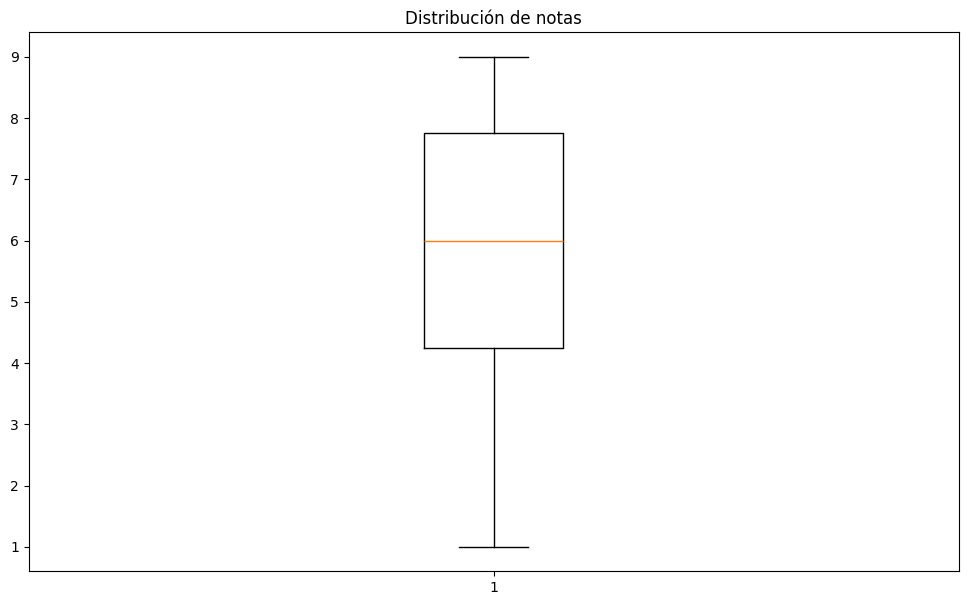

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

notas = [8,4,7,9,5,1]
alumnos = ['Jose', 'Juan', 'Daniel','Carla', 'Pablo','Pepe']
datos = {
    'alumno':alumnos,
    'nota': notas
}

df_notas = pd.DataFrame(datos)

def diagrama_cajas(df):
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.boxplot(df['nota'])
    plt.title('Distribución de notas')
    plt.show()

diagrama_cajas(df_notas)

Escribir una función que reciba un diccionario con las notas de las asignaturas de un curso y una cadena con el nombre de un color y devuelva un diagrama de barras de las notas en el color dado.

,asignatura,notas
0,Programación,5
1,Entornos,8
2,Análisis de datos,9
3,Estructuras de control,4


C:\Users\Jose Manuel\AppData\Local\Temp\ipykernel_25516\3431593593.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='C.E.D.A.P.')


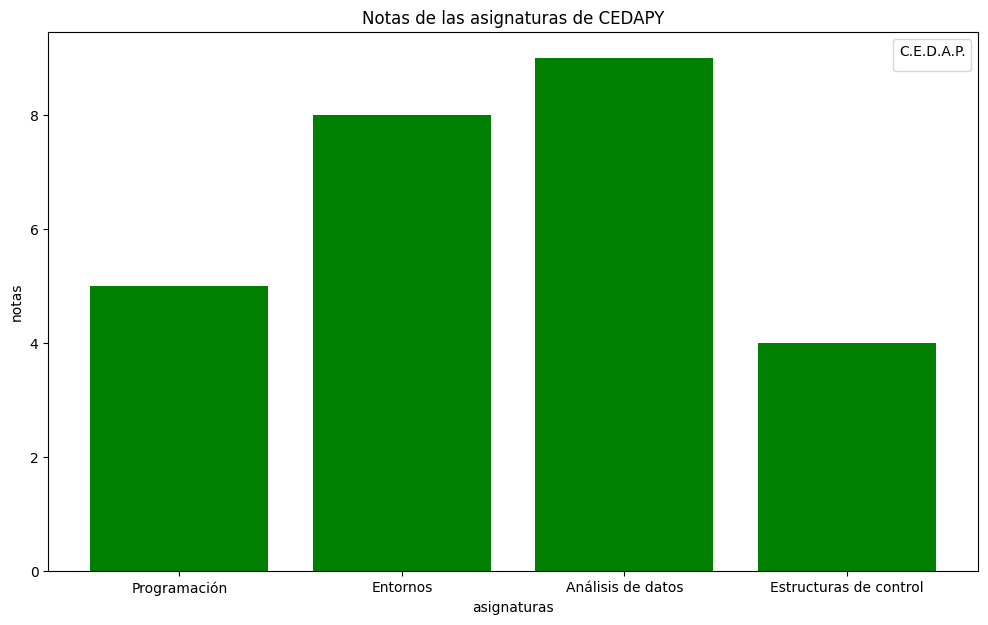

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

notas_curso = {
    'asignatura': ['Programación', 'Entornos', 'Análisis de datos', 'Estructuras de control'],
    'notas': [5,8,9,4],
}
tonalidad = 'green'
df_notas_color = pd.DataFrame(notas_curso)
display(df_notas_color.head())
def notas_color(df, cad):
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.bar(df['asignatura'], df['notas'], color= cad)
    ax.set_xlabel('asignaturas')
    ax.set_ylabel('notas')
    ax.legend(title='C.E.D.A.P.')
    plt.title('Notas de las asignaturas de CEDAPY')
    plt.show()

notas_color(df_notas_color, tonalidad)

Escribir un programa que pregunte al usuario por las ventas de un rango de años y muestre por pantalla un diagrama de líneas con la evolución de las ventas.

C:\Users\Jose Manuel\AppData\Local\Temp\ipykernel_25516\793705147.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Ventas/año')


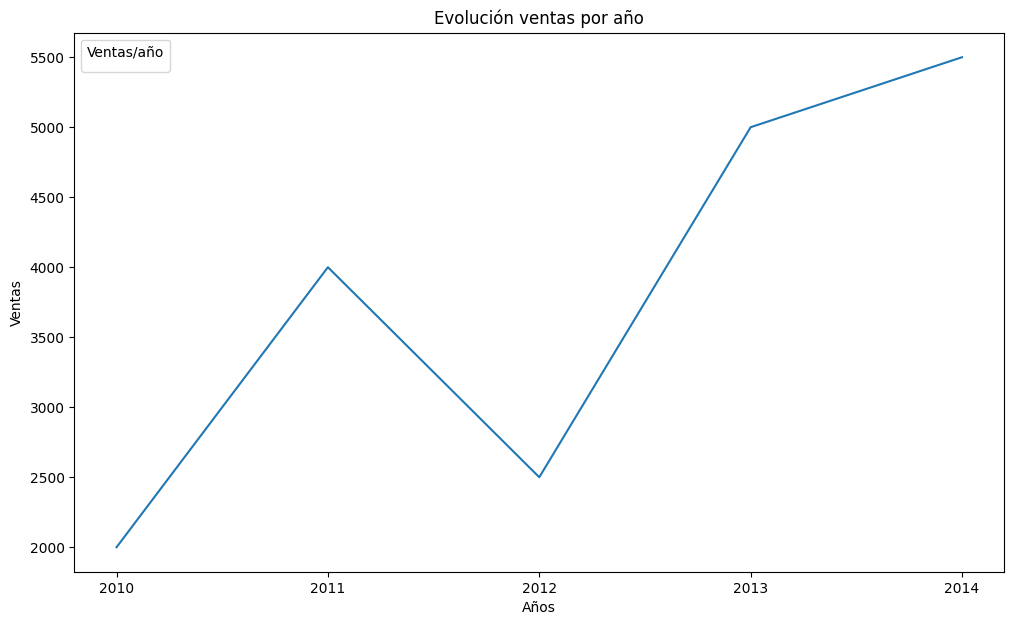

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

def rango_anios(rango):
    anio = 2010
    rango_end = rango + anio
    ventas_anios = []
    anios = []
    while(anio < rango_end):
        ventas = int(input("Introduce las ventas del año"))
        ventas_anios.append(ventas)
        anios.append(anio)
        anio +=1
    datos = {
        'año': anios,
        'ventas_año': ventas_anios
    }
    df_ventas = pd.DataFrame(datos)
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.plot(df_ventas['año'], df_ventas['ventas_año'])
    # formato_x = mticker.FormatStrFormatter('%.0f') para aplicar formato sin decimales
    # ax.xaxis.set_major_formatter(formato_x) para aplicar el formato al eje x
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))   # Usar MaxNLocator para asegurar que todas las marcas sean enteras.
                                                                    # Matplotlib elegirá las ubicaciones óptimas, pero solo de números enteros.         
    ax.set_xlabel('Años')
    ax.set_ylabel('Ventas')
    ax.legend(title='Ventas/año')
    plt.title('Evolución ventas por año')
    plt.show()

rango_anios(5)